<img src="http://www.cidaen.es/assets/img/mCIDaeNnb.png" alt="Logo CiDAEN" align="right">




<br><br><br>
<h2><font color="#00586D" size=4>Capstone I</font></h2>

<h1><font color="#00586D" size=5>Análisis de datos de Fórmula 1</font></h1>
<br><br><br>


<div align="right">
<font color="#00586D" size=3>Luis de la Ossa</font><br>
<font color="#00586D" size=3>Máster en Ciencia de Datos e Ingeniería de Datos en la Nube</font><br>
<font color="#00586D" size=3>Universidad de Castilla-La Mancha</font>

</div>

---

<a id="indice"></a>
<h2><font color="#00586D" size=5>Índice</font></h2>


* [1. Introducción](#section1)
* [2. Conductores](#section2)
* [3. Carreras y resultados](#section3)
* [4. Escuderías](#section4)
* [5. Circuitos](#section5)
* [6. Fernando Alonso vs rivales](#section6)
* [7. Conclusiones y líneas de trabajo para TFM](#section7)

---

In [3]:
from IPython.display import display, HTML
display(HTML("<style>.container {width:99%} </style>"))
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import style
style.use('seaborn-v0_8')

---

<a id="section1"></a>
## <font color="#00586D"> 1. Introducción</font>
<br>

En este primer proyecto del máster se trabajará con información sobre la competición de *Fórmula 1* generada desde el año 1950 hasta esta misma temporada. El conjunto datos se ha descargado  del sitio `ergast.com`, que es una base de datos sobre Fórmula 1 que proporciona una API para la consulta [(enlace)](http://ergast.com/mrd/), pero que también se puede descargar en formato (*MySQL*), o como un conjunto de 14 archivos `.csv` [(enlace)](http://ergast.com/mrd/db/).

A partir de este conjunto de datos se dará respuesta a una serie de cuestiones generales. También, como objetivo más concreto, se proporcionará una visión sobre la trayectoria (hasta el momento) del piloto español Fernando Alonso en esta competición. 

El enfoque de este trabajo, al igual que del primer módulo en su totalidad, es principalmente ***instrumental***. Por tanto, en lugar de llevar a cabo un análisis exploratorio de los datos como tal (esto lo haremos en el Capstone III), se abordarán una serie de ejercicios cuya resolución implicará manipular distintos *DataFrames*, y permitirá poner en práctica las habilidades adquiridas con *pandas* y *matplotlib*. En concreto, se pondrá el foco en *pandas*, ya que la visualización se trabajará en los módulos correspondientes.

Por último, y debido a que éste es el primero de varios proyectos, **la carga de trabajo es importante**. No obstante, os animamos a ampliar el trabajo y construir alguna gráfica más en relación a algún aspecto que despierte vuestra curiosidad. 

<div class="alert alert-block alert-info">
    
El texto marcado como <i class="fa fa-info-circle" aria-hidden="true"></i> corresponde a un desplegable con ***sugerencias*** que pueden ayudar a resolver los ejercicios. Os animamos, no obstante,  a hacer un intento de resolverlos antes de leerlas.
</div>

<div align="right">
<a href="#indice"><font size=5 color="#00586D"><i class="fa fa-arrow-circle-up" aria-hidden="true"></i></font></a>
</div>

---

<a id="section2"></a>
## <font color="#00586D"> 2. Conductores</font>
<br>

El archivo `data/drivers.csv` contiene información identificativa básica sobre los pilotos. Debido a que el proyecto se centrará también en un piloto concreto, `Fernando Alonso`, se tratará esta información en primer lugar.

### <font size=3 color="#00586D"> <i class="fa fa-pencil-square-o" aria-hidden="true" style="color:#00586D"></i> Ejercicio 1</font>

Cargar los datos del archivo `data/drivers.csv` en un *DataFrame* denominado `df_drivers`, mostrar la cabecera y, posteriormente, la información sobre la estructura del *DataFrame*.
<br><br>


<details>    
<summary>
    <font size=3 color="#00586D"> <i class="fa fa-info-circle"  aria-hidden="true"></i></font>
</summary>
    
* Cargar primero el conjunto de datos, sin utilizar ningún parámetro adicional.

</details>   

In [2]:
ls

 Volume in drive C is OSDisk
 Volume Serial Number is 30AC-60A4

 Directory of C:\Users\lufenufr\Documents\CIDAEN\mc5-m1-capstone

01/08/2025  06:17 PM    <DIR>          .
01/08/2025  06:17 PM    <DIR>          ..
12/27/2024  06:06 PM    <DIR>          .ipynb_checkpoints
01/08/2025  06:17 PM           434,589 Capstone I.ipynb
12/27/2024  06:04 PM    <DIR>          data
               1 File(s)        434,589 bytes
               4 Dir(s)   6,250,303,488 bytes free


In [4]:
df_drivers = pd.read_csv('data/drivers.csv')
df_drivers.head()

,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


In [4]:
df_drivers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 860 entries, 0 to 859
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   driverId     860 non-null    int64 
 1   driverRef    860 non-null    object
 2   number       860 non-null    object
 3   code         860 non-null    object
 4   forename     860 non-null    object
 5   surname      860 non-null    object
 6   dob          860 non-null    object
 7   nationality  860 non-null    object
 8   url          860 non-null    object
dtypes: int64(1), object(8)
memory usage: 60.6+ KB




En la información del *DataFrame* puede apreciarse que una columna, `driverId`, corresponde al identificador y se ha codificado como entero. El resto, se han codificado como objetos, incluyendo el número (`number`) o la fecha de nacimiento (`dob`). Además, se aprecia que la nacionalidad (`nationality`) podría ser tratada como una categoría. Aunque todos estos cambios se podrían hacer mediante operaciones (`DataFrame.set_index()` y `DataFrame.astype()`), parece más cómodo volver a leer el archivo.



Volver a cargar el archivo `data/drivers.csv` en un *DataFrame* denominado `df_drivers`. Utilizar ahora como índice la primera columna (`driverId`), que contiene el identificador individual de cada piloto.  Especificar que los valores perdidos se representan como `'\N'`, y que el tipo de datos de las columnas `driverRef`, `code`, `forename`, y `surname` debe ser `string`. Especificar también que `nationality` es una categoría, e indicar que se trate la columna `dob` como un dato temporal mediante el parámetro `parse_dates` de `pd.read_csv()`.

<br>

<details>    
<summary>
    <font size=3 color="#00586D"> <i class="fa fa-info-circle"  aria-hidden="true"></i> </font>
</summary>
   
* Se recomienda echar un vistazo a la primera libreta del tutorial de *Pandas*, en la que se vio `pd.read_csv()`.    
* Para especificar el valor `'\N'` puede utilizarse una secuencia de escape o un *raw string*.

</details>   



In [5]:
new_types = {
       'driverRef': 'string',
       'code': 'string',
       'forename': 'string',
       'surname': 'string',
       'nationality': 'category'
   }

df_drivers = pd.read_csv('data/drivers.csv',
   index_col='driverId',
   na_values='\\N',
   dtype= new_types,
   parse_dates=['dob']
)

df_drivers.head()

,driverRef,number,code,forename,surname,dob,nationality,url
driverId,,,,,,,,
1,hamilton,44.0,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
2,heidfeld,NaN,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
3,rosberg,6.0,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
4,alonso,14.0,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
5,kovalainen,NaN,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


In [ ]:
df_drivers.dtypes
df_drivers.info()


Extraer los datos relativos al piloto `Fernando Alonso`, cuyo código es `ALO`, y almacenarlos en una *Series* denominada `alonso_data`.  Almacenar el identificador correspondiente al piloto en la variable `alonso_id`. 

<br>

<details>    
<summary>
    <font size=3 color="#00586D"> <i class="fa fa-info-circle"  aria-hidden="true"></i> </font>
</summary>
   
* El resultado de la selección condicional es un *DataFrame* con una fila. Para convertirlo a *Series* se puede utilizar el método `DataFrame.squeeze()`.
* Por otra parte, el identificador es el nombre (`name`) de la *Series* resultante, que realmente corresponde al campo `driverId` de la fila accedida.

</details>   



In [6]:
alonso_id = df_drivers[df_drivers['code'] == 'ALO'].index[0]
alonso_data = df_drivers.loc[alonso_id]

<div><font size=3 color="#00586D"> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>

<!--comment -->



### <font  size=3 color=#00586D> <i class="fa fa-pencil-square-o" aria-hidden="true"></i> Ejercicio 2</font>

Mostrar las filas de `df_drivers`correspondientes a los cinco pilotos más jóvenes.

<br>

<details>    
<summary>
    <font size=3 color="#00586D"> <i class="fa fa-info-circle"  aria-hidden="true"></i> </font>
</summary>
   
* Existen varios métodos para obtener las filas correspondientes a los valores más altos de una columna. Se puede ordenar el *DataFrame* y acceder a las filas por posición, o devolver directamente las *n* filas con mayor valor mediante un método específico.

</details>   

In [7]:
youngest_drivers = df_drivers.sort_values('dob', ascending=False).head()
print(youngest_drivers)

          driverRef  number code forename    surname        dob  \
driverId                                                          
860         bearman    38.0  BEA   Oliver    Bearman 2005-05-08   
861       colapinto    43.0  COL   Franco  Colapinto 2003-05-27   
859          lawson    40.0  LAW     Liam     Lawson 2002-02-11   
857         piastri    81.0  PIA    Oscar    Piastri 2001-04-06   
858        sargeant     2.0  SAR    Logan   Sargeant 2000-12-31   

            nationality                                            url  
driverId                                                                
860             British    http://en.wikipedia.org/wiki/Oliver_Bearman  
861        Argentinian   http://en.wikipedia.org/wiki/Franco_Colapinto  
859       New Zealander       http://en.wikipedia.org/wiki/Liam_Lawson  
857          Australian     http://en.wikipedia.org/wiki/Oscar_Piastri  
858            American    http://en.wikipedia.org/wiki/Logan_Sargeant  


Elaborar, utilizando *matplotlib*, un gráfico de barras que represente el número de pilotos de cada nacionalidad que hay en el *DataFrame* `df_drivers`. Utilizar solamente los datos de las 20 naciones para las que hay más pilotos, añadir el título a la figura, y configurar las etiquetas de la escala del eje X (*ticks*) para que sean legibles.


<br>

<details>    
<summary>
    <font size=3 color="#00586D"> <i class="fa fa-info-circle"  aria-hidden="true"></i> </font>
</summary>
   
* Este ejercicio se puede hacer de varias formas, pero la más sencilla consiste en obtener el número de veces que aparece cada valor en la columna correspondiente (`nationality`) y tomar los veinte que aparecen de manera más frecuente.
* Existe un método en la API de `Series` que directamente devuelve el número de veces que aparece cada valor.
* En el ejercicio práctico de *pandas* y *matplotlib* se elaboraron varias gráficas de barras.

</details>   

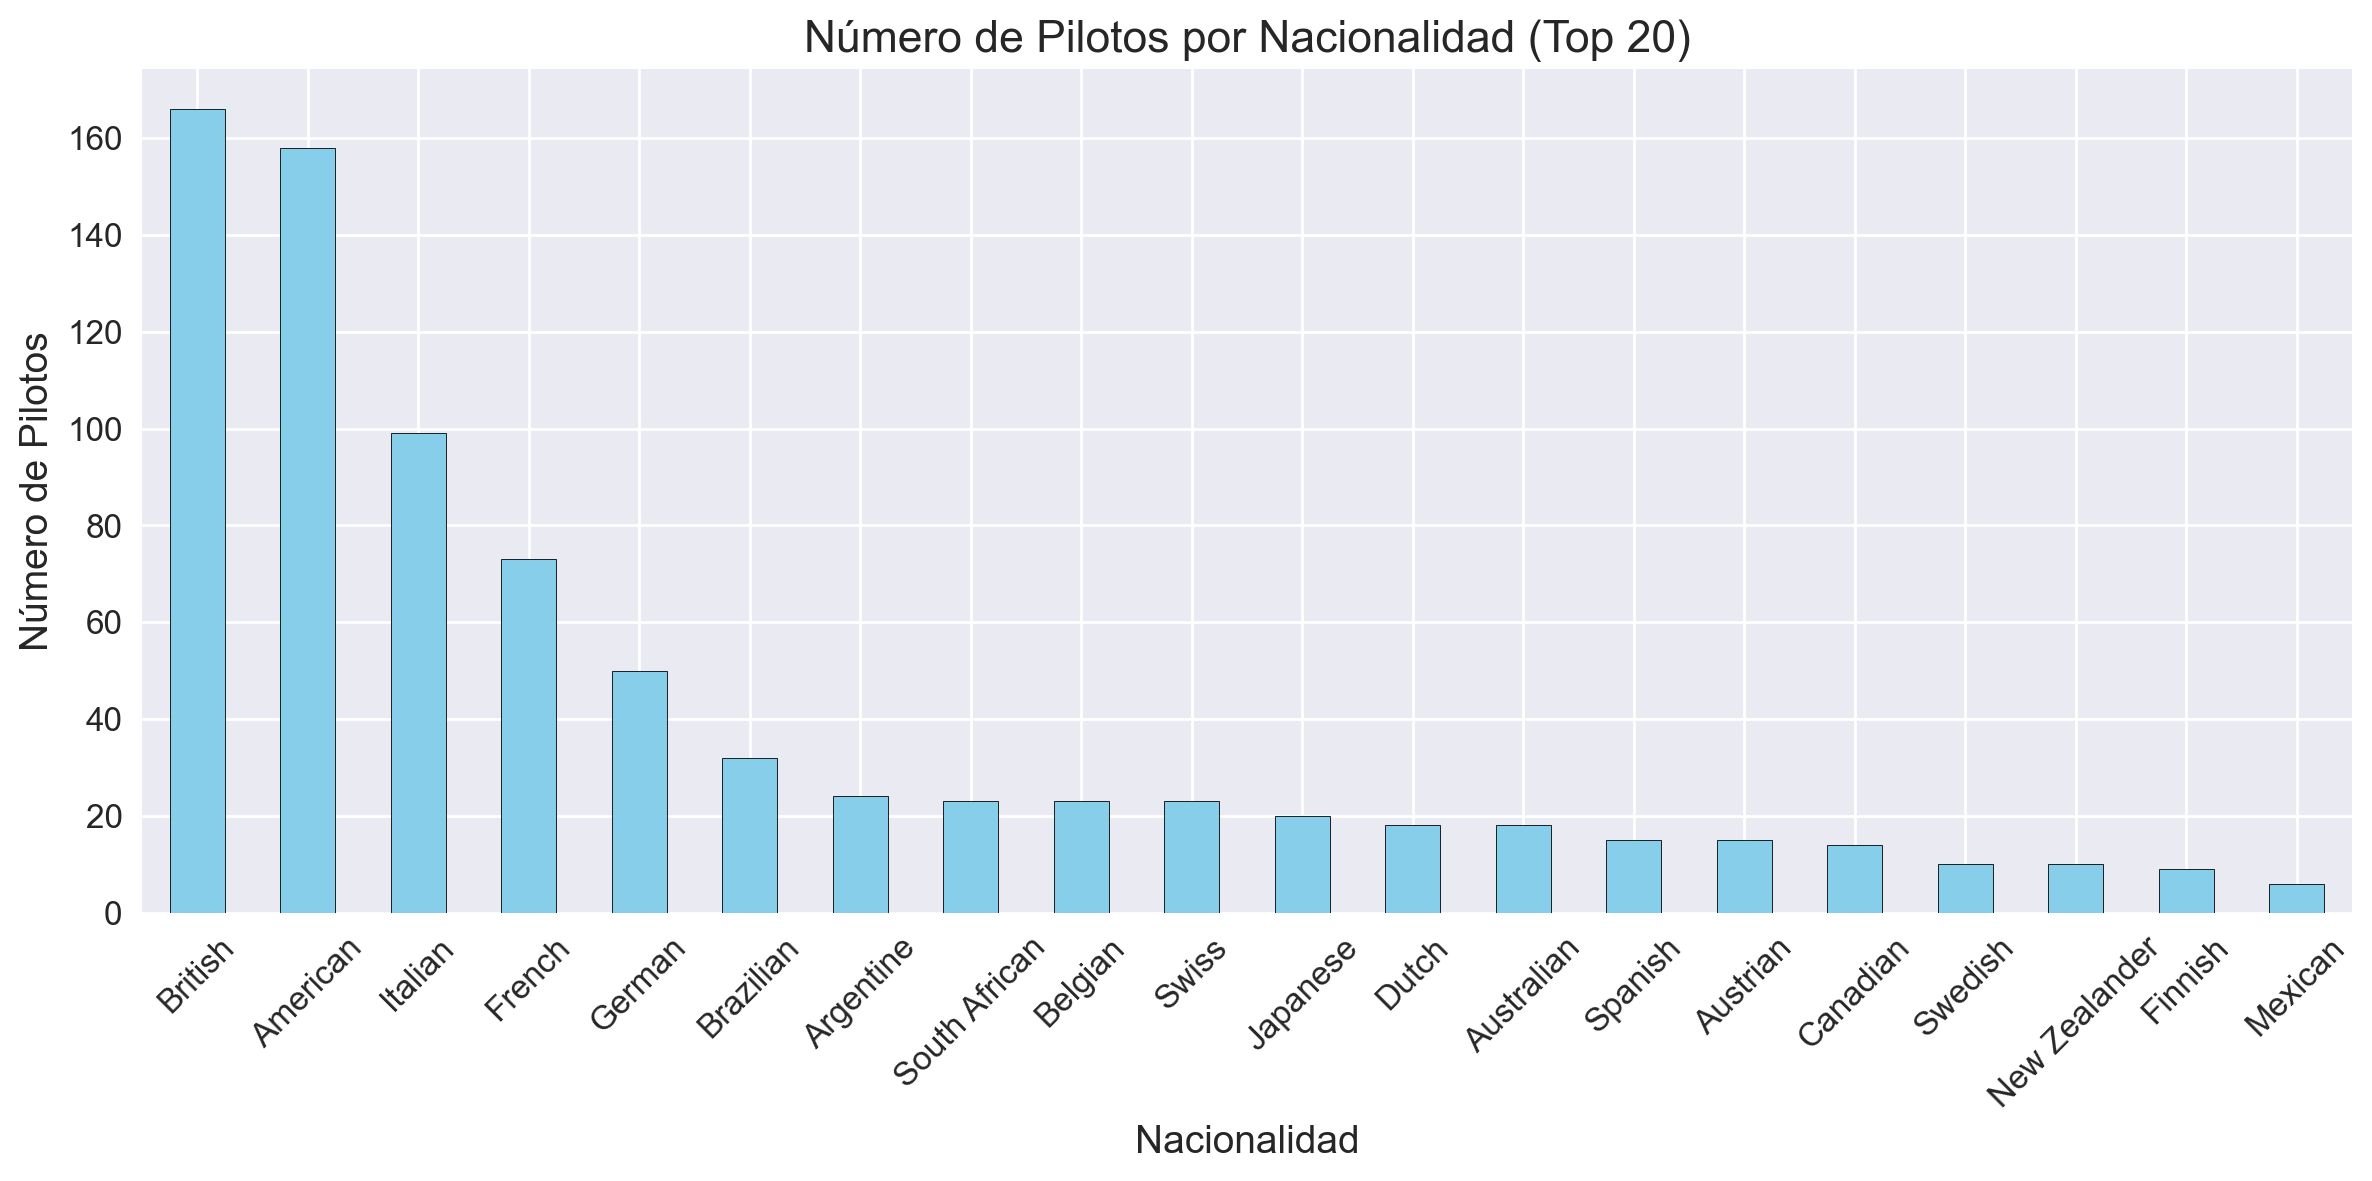

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

top_nationalities = df_drivers['nationality'].value_counts().head(20)

plt.figure(figsize=(12, 6))
top_nationalities.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Número de Pilotos por Nacionalidad (Top 20)', fontsize=16)
plt.xlabel('Nacionalidad', fontsize=14)
plt.ylabel('Número de Pilotos', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()


<div><font size=3 color="#00586D"> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>

<!--comment -->

<div align="right">
<a href="#indice"><font size=5 color="#00586D"><i class="fa fa-arrow-circle-up" aria-hidden="true"></i></font></a>
</div>

---

<a id="section3"></a>
## <font color="#00586D"> 3. Carreras y resultados</font>
<br>

Una vez procesados los datos relativos a pilotos, se analizará la información más importante en este conjunto de datos: los resultados.



### <font  size=3 color="#00586D"> <i class="fa fa-pencil-square-o" aria-hidden="true" style="color:#00586D"></i> Ejercicio 3</font>  

El conjunto de datos `data/races.csv` contiene información *general* relativa a cada una de las carreras, y que consiste en aspectos como el nombre, circuito, fecha, etc. Almacenarlo en un *DataFrame* denominado `df_races`, utilizando la columna `raceId` (la primera) como índice. Especificar que el campo `date` ha de considerarse como una fecha. Utilizar para ello el parámetro `parse_dates`. 

In [9]:
df_races = pd.read_csv(
    'data/races.csv',
    index_col='raceId',
    parse_dates=['date']
)

df_races.head()

,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
raceId,,,,,,,,,,,,,,,,,
1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


Inspeccionar el *DataFrame*. ¿Cuántos valores perdidos hay en la columna `time`?

In [10]:
unique_times = df_races['time'].unique()
print("Valores únicos en la columna 'time':")
print(unique_times)


Valores únicos en la columna 'time':
['06:00:00' '09:00:00' '07:00:00' '12:00:00' '05:00:00' '16:00:00'
 '11:00:00' '04:30:00' '11:30:00' '17:00:00' '03:00:00' '14:30:00'
 '15:00:00' '14:00:00' '13:00:00' '\\N' '08:00:00' '09:30:00' '18:00:00'
 '19:00:00' '20:00:00' '05:10:00' '15:10:00' '06:10:00' '12:10:00'
 '13:10:00' '18:10:00' '14:10:00' '11:10:00' '19:10:00' '17:10:00'
 '10:10:00' '17:30:00' '19:30:00' '04:00:00']


In [11]:
missing_time = (df_races['time'] == '\\N').sum()
print(f"Valores perdidos en la columna 'time' (representados por '\\N'): {missing_time}")


Valores perdidos en la columna 'time' (representados por '\N'): 731


Al inspeccionar el *DataFrame* se observa que la columna `time` está expresada como una cadena de texto. Generar una nueva *Series* con los valores de la columna `time` convertidos a marcas de tiempo.  ¿Qué se aprecia con respecto a la fecha? 


<br>

<details>    
<summary>
    <font size=3 color="#00586D"> <i class="fa fa-info-circle"  aria-hidden="true"></i> </font>
</summary>
   
* Utilizar `pd.to_datetime()`.    
* Para evitar un `warning` es necesario especificar `format='mixed'`.
* No es necesario almacenar la *Series*, solo mostrarla. **No** sobreescribir la columna `Time`.
</details>  

In [12]:
pd.to_datetime(df_races['time'], errors='coerce', format='mixed')

raceId
1      2025-01-09 06:00:00
2      2025-01-09 09:00:00
3      2025-01-09 07:00:00
4      2025-01-09 12:00:00
5      2025-01-09 12:00:00
               ...        
1140   2025-01-09 20:00:00
1141   2025-01-09 17:00:00
1142   2025-01-09 06:00:00
1143   2025-01-09 17:00:00
1144   2025-01-09 13:00:00
Name: time, Length: 1125, dtype: datetime64[ns]

In [13]:
print('Al usar la funcion "to_datetime" en una columna sin fecha, pandas infiere la fecha usando la fecha actual.')

Al usar la funcion "to_datetime" en una columna sin fecha, pandas infiere la fecha usando la fecha actual.


Crear una columna denominada `df_races[date time]` en la que se represente la fecha y hora en la que tuvo lugar cada carrera. Para ello, es necesario convertir a `TimeDelta` el contenido (codificado como `string`) de la columna `time`, y sumárselo a la columna `date`. Como se ha visto anteriormente, hay muchos valores perdidos. Antes de hacer la conversión, sustituir estos valores por el `string` `'12:00:00'`.



<br>

<details>    
<summary>
    <font size=3 color="#00586D"> <i class="fa fa-info-circle"  aria-hidden="true"></i> </font>
</summary>
   
* La conversión a `TimeDelta` se hace con `pd.to_timedelta()`. 
* Esa función se ha de aplicar a la serie `df_races['time']` una vez se hayan sustituído los valores perdidos.
</details>  

In [14]:
df_races['time'] = df_races['time'].replace('\\N', '12:00:00')
df_races['time'] = pd.to_timedelta(df_races['time'])
df_races['date time'] = df_races['date'] + df_races['time']
print(df_races['date time'])


raceId
1      2009-03-29 06:00:00
2      2009-04-05 09:00:00
3      2009-04-19 07:00:00
4      2009-04-26 12:00:00
5      2009-05-10 12:00:00
               ...        
1140   2024-10-27 20:00:00
1141   2024-11-03 17:00:00
1142   2024-11-23 06:00:00
1143   2024-12-01 17:00:00
1144   2024-12-08 13:00:00
Name: date time, Length: 1125, dtype: datetime64[ns]


In [15]:
df_races.head()

,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time,date time
raceId,,,,,,,,,,,,,,,,,,
1,2009,1,1,Australian Grand Prix,2009-03-29,0 days 06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,2009-03-29 06:00:00
2,2009,2,2,Malaysian Grand Prix,2009-04-05,0 days 09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,2009-04-05 09:00:00
3,2009,3,17,Chinese Grand Prix,2009-04-19,0 days 07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,2009-04-19 07:00:00
4,2009,4,3,Bahrain Grand Prix,2009-04-26,0 days 12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,2009-04-26 12:00:00
5,2009,5,4,Spanish Grand Prix,2009-05-10,0 days 12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,2009-05-10 12:00:00


Eliminar las columnas `round`, `date` y `time`. También las relativas a las horas de entrenamiento libres (`fpx_`), calificaciones (`qualy_`) y sprints (`sprint_`). Mover la nueva columna, `date time`, a la posición que ocupaba `date`. Es decir, el *DataFrame* resultante debe tener 5 columnas: `year`, `name`, `circuitId`, `date time` y `url`.



<br>

<details>    
<summary>
    <font size=3 color="#00586D"> <i class="fa fa-info-circle"  aria-hidden="true"></i> </font>
</summary>
   
* En este caso, lo más sencillo para hacerlo es seleccionar las columnas de interés en el orden que se pide.
</details>  

In [16]:
df_races = df_races[['year', 'name', 'circuitId', 'date time', 'url']]
df_races.head()

,year,name,circuitId,date time,url
raceId,,,,,
1,2009,Australian Grand Prix,1,2009-03-29 06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...
2,2009,Malaysian Grand Prix,2,2009-04-05 09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...
3,2009,Chinese Grand Prix,17,2009-04-19 07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...
4,2009,Bahrain Grand Prix,3,2009-04-26 12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...
5,2009,Spanish Grand Prix,4,2009-05-10 12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...


¿Cuales son la primera y última carrera que contiene el *DataFrame*? (Mostrarlas como un *DataFrame* de dos filas)

In [17]:
first_race = df_races.loc[df_races['date time'].idxmin()]
last_race = df_races.loc[df_races['date time'].idxmax()]
result = pd.DataFrame([first_race, last_race])
print(result)


      year                  name  circuitId           date time  \
833   1950    British Grand Prix          9 1950-05-13 12:00:00   
1144  2024  Abu Dhabi Grand Prix         24 2024-12-08 13:00:00   

                                                    url  
833   http://en.wikipedia.org/wiki/1950_British_Gran...  
1144  https://en.wikipedia.org/wiki/2024_Abu_Dhabi_G...  


<div><font size=3 color="#00586D"> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>

<!--comment -->

Una vez obtenidos los datos relativos a pilotos y carreras, se trabajará con la fuente de información  más importante en este conjunto de datos: los resultados de las carreras, que están recogidos en el archivo `data/results.csv`. Cada fila contiene información sobre la participación de un piloto (`driverId`) en una carrera (`raceId`). Además de la posición, contiene información relativa a tiempos, vuelta más rápida, mayor velocidad, etc, que también permitirá hacer otros análisis posteriormente.

### <font  size=3 color="#00586D"> <i class="fa fa-pencil-square-o" aria-hidden="true" style="color:#00586D"></i> Ejercicio 4</font>  

El archivo `data/results.csv` contiene los resultados de todas las carreras. Cargar los datos en el *DataFrame* `df_results`. Utilizar la primera columna (`resultId`) como índice. Especificar, igual que anteriormente, que los valores perdidos se representan con `'\N'`. Mostrar la cabecera.


<br>

<details>    
<summary>
    <font size=3 color="#00586D"> <i class="fa fa-info-circle"  aria-hidden="true"></i> </font>
</summary>
   
* Se recomienda echar un vistazo a la primera libreta, en la que se vió `pd.read_csv()`.    
* Para especificar el valor `'\N'` puede utilizarse una secuencia de escape o un *raw string*.

</details>   

In [18]:
df_results = pd.read_csv('data/results.csv', index_col=0, na_values='\\N')
df_results.head()

,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
resultId,,,,,,,,,,,,,,,,,
1,18,1,1,22.0,1,1.0,1,1,10.0,58,1:34:50.616,5690616.0,39.0,2.0,1:27.452,218.300,1
2,18,2,2,3.0,5,2.0,2,2,8.0,58,+5.478,5696094.0,41.0,3.0,1:27.739,217.586,1
3,18,3,3,7.0,7,3.0,3,3,6.0,58,+8.163,5698779.0,41.0,5.0,1:28.090,216.719,1
4,18,4,4,5.0,11,4.0,4,4,5.0,58,+17.181,5707797.0,58.0,7.0,1:28.603,215.464,1
5,18,5,1,23.0,3,5.0,5,5,4.0,58,+18.014,5708630.0,43.0,1.0,1:27.418,218.385,1


In [19]:
df_results.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26679 entries, 1 to 26684
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   raceId           26679 non-null  int64  
 1   driverId         26679 non-null  int64  
 2   constructorId    26679 non-null  int64  
 3   number           26673 non-null  float64
 4   grid             26679 non-null  int64  
 5   position         15741 non-null  float64
 6   positionText     26679 non-null  object 
 7   positionOrder    26679 non-null  int64  
 8   points           26679 non-null  float64
 9   laps             26679 non-null  int64  
 10  time             7625 non-null   object 
 11  milliseconds     7625 non-null   float64
 12  fastestLap       8177 non-null   float64
 13  rank             8430 non-null   float64
 14  fastestLapTime   8177 non-null   object 
 15  fastestLapSpeed  8177 non-null   float64
 16  statusId         26679 non-null  int64  
dtypes: float64(7), in

Elaborar un gráfico de barras horizontal que muestre el número de carreras disputadas por los diez pilotos que más carreras han disputado. La etiqueta de cada barra debe mostrar el nombre (`surname`) del piloto correspondiente.


<br>

<details>    
<summary>
    <font size=3 color="#00586D"> <i class="fa fa-info-circle"  aria-hidden="true"></i> </font>
</summary>
   
* En este caso no es necesario complicar la consulta.    
* Se pueden obtener directamente los valores que más aparecen en la columna `driverId`,  almacenarlos en un *DataFrame* intermedio, y posteriormente acceder a los nombres de los pilotos para etiquetar los *ticks* del eje $Y$.
* Para que la barra correspondiente al piloto con más carreras se sitúe en la parte superior, se puede utilizar el método `ax.invert_yaxis()`.


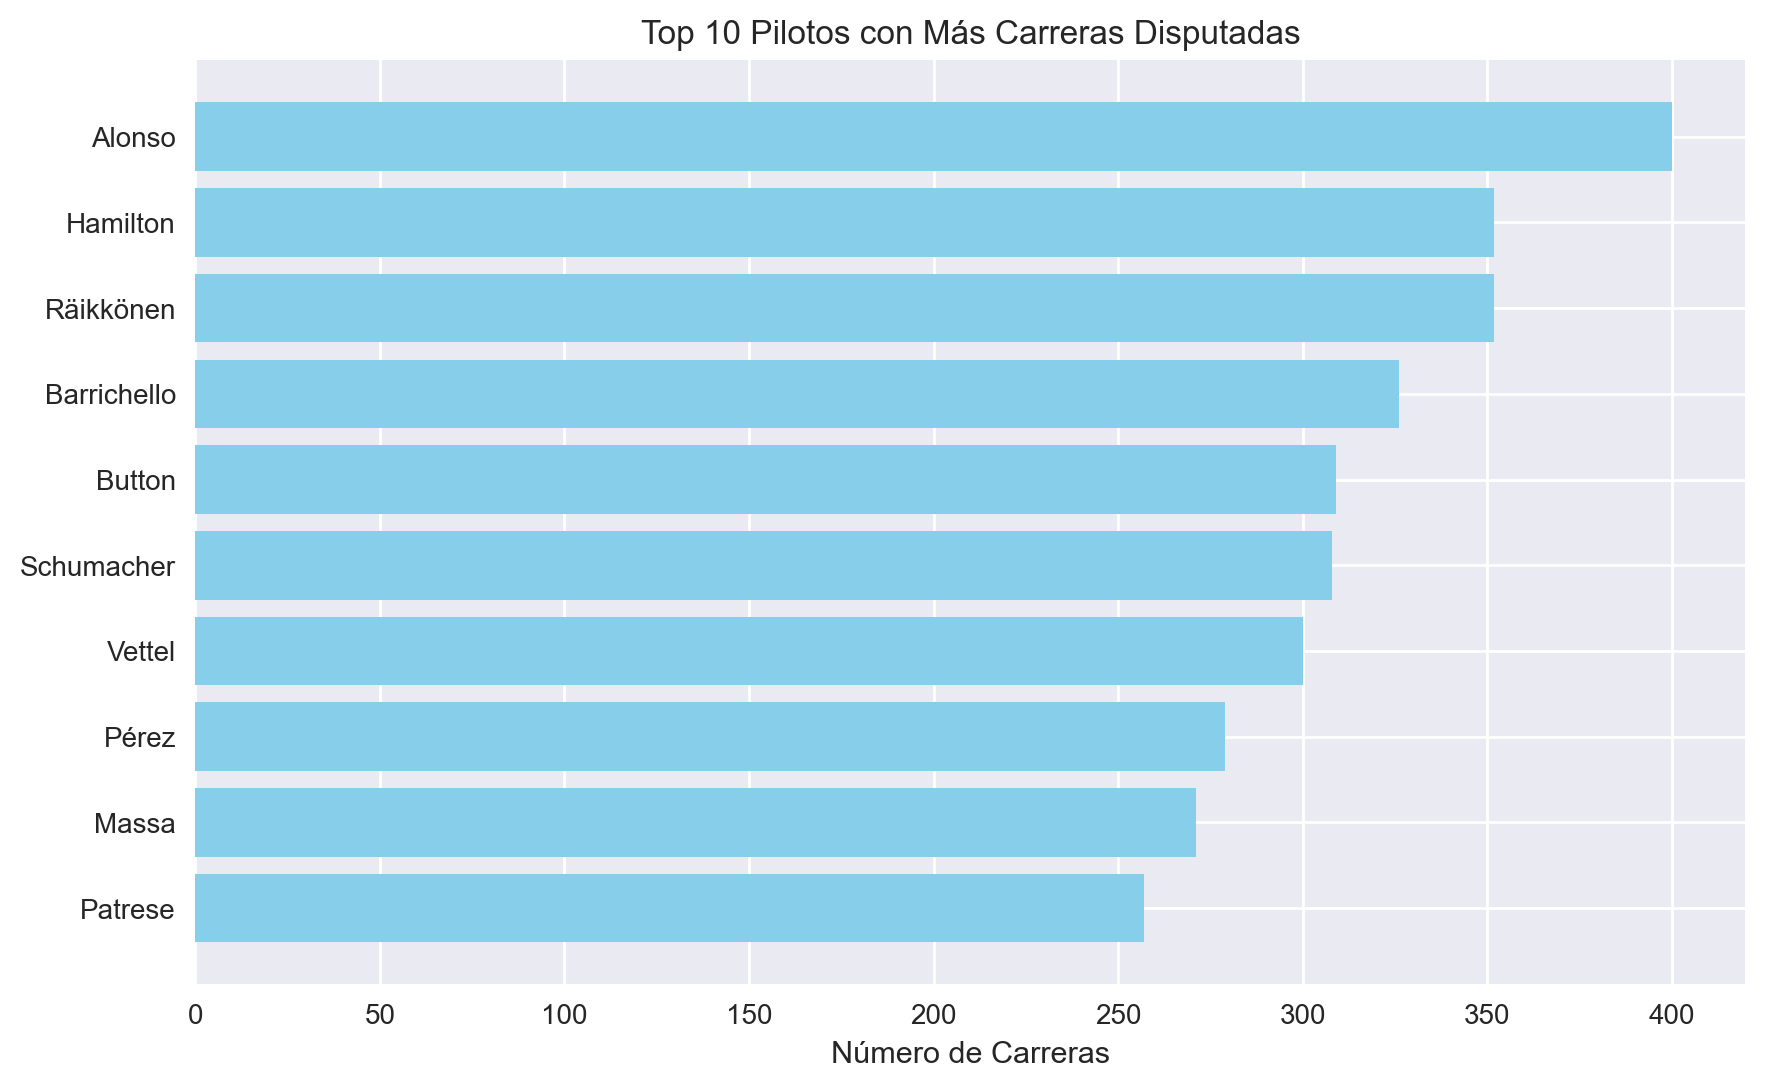

In [20]:
top_drivers = df_results['driverId'].value_counts().head(10)
top_drivers_df = top_drivers.reset_index()
top_drivers_df.columns = ['driverId', 'race_count']
top_drivers_df = top_drivers_df.merge(df_drivers[['surname']], left_on='driverId', right_index=True, how='left')

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_drivers_df['surname'], top_drivers_df['race_count'], color='skyblue')
ax.set_xlabel('Número de Carreras')
ax.set_title('Top 10 Pilotos con Más Carreras Disputadas')
ax.invert_yaxis()

plt.show()


<span style="color:red;">investigar!!!</span>
problema en el merge porque raceID o driverID son indices del df, 


<div><font size=3 color="#00586D"> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>

<!--comment -->


### <font  size=3 color="#00586D"> <i class="fa fa-pencil-square-o" aria-hidden="true" style="color:#00586D"></i> Ejercicio 5</font>

¿Qué pilotos han ganado las 5 últimas carreras?

<br>

<details>    
<summary>
    <font size=3 color="#00586D"> <i class="fa fa-info-circle"  aria-hidden="true"></i> </font>
</summary>
   
* Se trata de seleccionar los resultados con `position==1`, fundir primero con `df_races[['name','date time']]`, después con `df_drivers['driverRef']`, y devolver las cinco filas del *DataFrame* resultante con los valores más altos de `date_time`.
* En realidad se puede cambiar el orden de las operaciones para que sea más eficiente (seleccionando las cinco filas antes del último `merge`).

In [64]:
winners = df_results[df_results['positionOrder'] == 1]
winners = winners.merge(df_races[['name', 'date time']], left_on='raceId', right_index=True, how='left')
winners['date time'] = pd.to_datetime(winners['date time'])
recent_winners = winners.nlargest(5, 'date time')
recent_winners = recent_winners.merge(df_drivers[['driverRef']], left_on='driverId', right_index=True, how='left')

print(recent_winners[['name', 'date time', 'driverRef']])


                              name           date time driverRef
resultId                                                        
26665       Mexico City Grand Prix 2024-10-27 20:00:00     sainz
26645     United States Grand Prix 2024-10-20 19:00:00   leclerc
26625         Singapore Grand Prix 2024-09-22 12:00:00    norris
26605        Azerbaijan Grand Prix 2024-09-15 11:00:00   piastri
26585           Italian Grand Prix 2024-09-01 13:00:00   leclerc


<div><font size=3 color="#00586D"> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>

<!--comment -->



### <font  size=3 color="#00586D"> <i class="fa fa-pencil-square-o" aria-hidden="true" style="color:#00586D"></i> Ejercicio 6</font>


Mostrar un *DataFrame* con el nombre, apellido, nacionalidad y número de victorias de los cinco pilotos que acumulan más victorias.


<br>

<details>    
<summary>
    <font size=3 color="#00586D"> <i class="fa fa-info-circle"  aria-hidden="true"></i> </font>
</summary>
   
Este ejercicio se puede resolver en varios pasos.
    
1. La victoria se representa con el  valor 1 en la columna `position`. Se han de seleccionar los resultados correspondientes a victorias y almacenarlos en un nuevo *DataFrame*.
2. Sobre el *DataFrame* anterior, agrupar por conductor, calcular el tamaño de cada grupo y devolver los 10 mayores grupos y su tamaño. Alternativamente, y de forma más eficiente, se puede contar el número de veces que aparece cada valor `driverId`. Como se opera sobre una *Series*, el resultado es otra *Series* que se puede convertir en *DataFrame* mediante `Series.to_frame()`. En ese *DataFrame* resultante se puede renombrar la única existente a `wins`.
3. Se debe hacer un `pd.merge()` entre el *DataFrame* obtenido y `df_drivers`.En todos las operaciones de fusión se ha de tener en cuenta qué índices se incluyen en el *DataFrame* resultante.
4. Por último, se accede a las columnas de interés: nombre y apellido del piloto, nacionalidad, y victorias.    
    
</details>  


In [21]:
victories = df_results[df_results['positionOrder'] == 1]

victory_counts = victories['driverId'].value_counts().head(5).to_frame(name='wins')
victory_counts.index.name = 'driverId'

top_winners = victory_counts.merge(df_drivers[['forename', 'surname', 'nationality']], 
                                   left_index=True, right_index=True, how='left')

top_winners = top_winners[['forename', 'surname', 'nationality', 'wins']]

print(top_winners)


           forename     surname nationality  wins
driverId                                         
1             Lewis    Hamilton     British   105
30          Michael  Schumacher      German    91
830             Max  Verstappen       Dutch    61
20        Sebastian      Vettel      German    53
117           Alain       Prost      French    51


Mostrar el nombre, apellido, nacionalidad y número *pole positions* de los cinco pilotos que más sesiones de calificación han ganado. La posición de un piloto en la calificación de cada carrera viene dada por la columna `grid`.

<br>

<details>    
<summary>
    <font size=3 color="#00586D"> <i class="fa fa-info-circle"  aria-hidden="true"></i> </font>
</summary>
   
* Este ejercicio es similar al anterior, pero en este caso hay que acceder a las filas correspondientes a las calificaciones (`grid`), y el *DataFrame* debe incluir una columna denominada `poles` en lugar de `wins`.  
* Se valorará adicionalmente el resolver el ejercicio mediante *method chaining*, sin crear estructuras de datos intermedias.
    
</details>  


In [23]:
top_pole_positions = (
    df_results[df_results['grid'] == 1] 
    .groupby('driverId')  
    .size()  
    .nlargest(5)  
    .to_frame(name='poles') 
    .merge(df_drivers[['forename', 'surname', 'nationality']], left_index=True, right_index=True, how='left') 
    .reset_index()  # Restablecer el índice
    [['forename', 'surname', 'nationality', 'poles']]  
)

print(top_pole_positions)


    forename     surname nationality  poles
0      Lewis    Hamilton     British    104
1    Michael  Schumacher      German     68
2     Ayrton       Senna   Brazilian     65
3  Sebastian      Vettel      German     57
4        Max  Verstappen       Dutch     40


Mostrar el nombre, apellido, nacionalidad y número de vueltas rápidas de los cinco pilotos que más vueltas rápidas han conseguido. El ranking del piloto en relación a su mejor vuelta en una carrera se almacena en la columna  `rank`.

<br>

<details>    
<summary>
    <font size=3 color="#00586D"> <i class="fa fa-info-circle"  aria-hidden="true"></i> </font>
</summary>
   
* Este ejercicio es similar a los anteriores, pero en este caso hay que acceder a las filas correspondientes al ranking en vuelta rápida (`rank`), y el *DataFrame* debe incluir una columna denominada `fastestLaps` en lugar de `wins` o `poles`.  
* Se valorará adicionalmente el resolver el ejercicio mediante *method chaining*, sin crear estructuras de datos intermedias.
    
</details>  

In [40]:
top_fastest_laps = (
    df_results[df_results['rank'] == 1]  # Filtrar las filas donde el piloto tiene la vuelta más rápida (rank == '1')
    .groupby('driverId')  # Agrupar por driverId
    .size()  # Contar el número de vueltas rápidas por piloto
    .nlargest(5)  # Seleccionar los 5 pilotos con más vueltas rápidas
    .to_frame(name='fastestLaps')  # Convertir a DataFrame y renombrar la columna a 'fastestLaps'
    .merge(df_drivers[['forename', 'surname', 'nationality']], left_index=True, right_index=True, how='left')  # Combinar con df_drivers
    .reset_index()  # Restablecer el índice
    [['forename', 'surname', 'nationality', 'fastestLaps']]  # Seleccionar las columnas deseadas
)

print(top_fastest_laps)


    forename     surname nationality  fastestLaps
0      Lewis    Hamilton     British           66
1       Kimi   Räikkönen     Finnish           42
2  Sebastian      Vettel      German           38
3        Max  Verstappen       Dutch           32
4   Fernando      Alonso     Spanish           25


<div><font size=3 color="#00586D"> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>

<!--comment -->


### <font  size=3 color="#00586D"> <i class="fa fa-pencil-square-o" aria-hidden="true" style="color:#00586D"></i> Ejercicio 7</font>

Calcular las posiciones que, de media, han ganado los pilotos **en las carreras finalizadas**. Mostrar el resultado para los cinco pilotos que más destacan en este aspecto, junto a su nombre, apellidos y nacionalidad.

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i> __Nota__: Este ejercicio **es  difícil**. 
</div>


<br>

<details>    
<summary>
    <font size=3 color="#00586D"> <i class="fa fa-info-circle"  aria-hidden="true"></i> </font>
</summary>
  
    
* Crear una nuevo `DataFrame` que incorpore una columna denominada `pos_won` obtenida al operar con las columnas `grid` y `position`, y a partir de los resultados correspondientes a carreras terminadas (en los que `statusId==1`). Se puede hacer creando la nueva columna, o un nuevo *DataFrame* mediante `DataFrame.assign()`.
    
* Prestad atención a cómo se ordenan las operaciones, en general. Por ejemplo, en el caso anterior, si primero se hace la selección condicional, a `DataFrame.assign()` se le pasa un conjunto de datos más pequeño.
    
* El *DataFrame* resultante se ha de agrupar por piloto, se ha de obtener la media de la columna `pos_won` y seleccionar los cinco mayores valores. Como el resultado es una *Series*, se debe convertir a *DataFrame* con `Series.to_frame()`. También se puede generar directamente un *DataFrame* accediendo a la columna mediante una lista de un elemento.
    
* El resultado se ha de fundir con la `df_drivers`. Es importante gestionar bien cómo (`how`).
    
* Por último, devolver las columas `forename`, `surname`, `nationality` y `pos_won` del resultado de la fusión.
    
* Este ejercicio se puede hacer de forma elegante, sin crear explícitamente estructuras intermedias, mediante *method chaining*, aunque recomendamos encarecidamente dejar esto para el final, cuando se tenga el Capstone resuelto.
    

    
</details> 



In [42]:
top_positions_won = (
    df_results[df_results['statusId'] == 1]  
    .assign(pos_won=lambda df: df['grid'] - df['positionOrder']) 
    .groupby('driverId')['pos_won']  
    .mean()  
    .nlargest(5)  
    .to_frame(name='pos_won')  
    .merge(df_drivers[['forename', 'surname', 'nationality']], left_index=True, right_index=True, how='left')  
    [['forename', 'surname', 'nationality', 'pos_won']] 
)

print(top_positions_won)


          forename     surname nationality  pos_won
driverId                                           
659          Jerry        Hoyt    American     24.0
734          Bobby        Ball    American     24.0
560           Bill  Cheesbourg    American     23.0
591         George       Amick    American     23.0
613       Marshall      Teague    American     21.0


¿Cuantas carreras ha disputado y concluido el piloto más destacado en este aspecto?

In [46]:
races_concluded = (
    df_results[df_results['statusId'] == 1]  
    .assign(pos_won=lambda df: df['grid'] - df['positionOrder'])  
    .groupby('driverId')['pos_won']  
    .mean() 
    .nlargest(1)  
    .pipe(lambda s: df_results[(df_results['driverId'] == s.index[0]) & (df_results['statusId'] == 1)]) 
    .shape[0]  
)

print(races_concluded)


1


Puede apreciarse que la información está viciada porque incluye a pilotos que han competido muy pocas veces y les ha ido muy bien. Repetir el ejercicio anterior, pero utilizando solamente datos de aquellos pilotos que han finalizado al menos 50 carreras.


<br>

<details>    
<summary>
    <font size=3 color="#00586D"> <i class="fa fa-info-circle"  aria-hidden="true"></i> </font>
</summary>
  
    
* Este ejercicio es similar al anterior, pero hay que incorporar un paso intermedio. Una vez obtenidas las posiciones ganadas a partir de `df_results`, computando la diferencia entre `grid` y `posición` en todos los resultados correspondientes a carreras terminadas (`statusId==1`), hay que filtrar los resultados correspondientes a los pilotos que han concluido 50 carreras o más. Para ello, se ha de utilizar `DataFrame.groupby().filter()`.
    
* A pesar de la complejidad, también se puede hacer este ejercicio mediante *method chaining*.

* Hay que acostumbrarse a hacer las operaciones en orden. En este caso, se puede seleccionar y filtrar primero, con lo que se descarta mucha información irrelevante antes del `DataFrame.assign()`.
    
    
</details> 


In [47]:
races_concluded_filtered = (
    df_results[df_results['statusId'] == 1]  
    .groupby('driverId') 
    .filter(lambda x: len(x) >= 50) 
    .assign(pos_won=lambda df: df['grid'] - df['positionOrder'])  
    .groupby('driverId')['pos_won']  
    .mean()  
    .nlargest(1)  
    .pipe(lambda s: df_results[(df_results['driverId'] == s.index[0]) & (df_results['statusId'] == 1)]) 
    .shape[0]  
)

races_concluded_filtered


61

<div><font size=3 color="#00586D"> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>

<!--comment -->

### <font  size=3 color="#00586D"> <i class="fa fa-pencil-square-o" aria-hidden="true" style="color:#00586D"></i> Ejercicio 8</font>  

La columna `statusId` de `df_results` contiene un código numérico que representa el estado en que cada coche/piloto concluyó cada carrera. El conjunto de datos `data/status.csv` contiene la descripción del estado. Leer este archivo y almacenarlo en el *DataFrame*. `df_status`.

In [48]:
df_status = pd.read_csv('data/status.csv')
df_status.head()

,statusId,status
0,1,Finished
1,2,Disqualified
2,3,Accident
3,4,Collision
4,5,Engine


Utilizar ambos *DataFrames*, `df_results` y `df_status`, para elaborar un diagrama de sectores en el que se visualicen las 10 causas más frecuentes que han impedido terminar a los pilotos las carreras en condiciones normales. Utilizar un tamaño de figura $6 \times 6$.



<br>

<details>    
<summary>
    <font size=3 color="#00586D"> <i class="fa fa-info-circle"  aria-hidden="true"></i> </font>
</summary>
   
* Hay que obtener el número de veces que aparece cada estado de terminación dentro del *DataFrame* `df_results` y obtener los once más frecuentes. Por otra parte, el estado 1 representa la finalización, por lo que hay que descartarlo. El resultado se puede almacenar en una serie denominada `causes`.
* Para elaborar la gráfica hay que obtener los nombres de los estados a partir de los códigos obtenidos y desde el DataFrame `df_status` y utilizarlos como etiqueta.
* Los diagramas de sectores se hacen con `plt.pie()` / `ax.pie()`. Podéis consultar la API [**(+inf)**](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pie.html) o ejemplos [**(+inf)**](https://matplotlib.org/stable/gallery/pie_and_polar_charts/pie_and_donut_labels.html#sphx-glr-gallery-pie-and-polar-charts-pie-and-donut-labels-py).
* Se considera que cuando el piloto llega con vueltas de retraso (`+1 Lap`, `+2 Laps`, etc.) no es una terminación normal, por lo que también deben aparecer en el gráfico.

</details>  



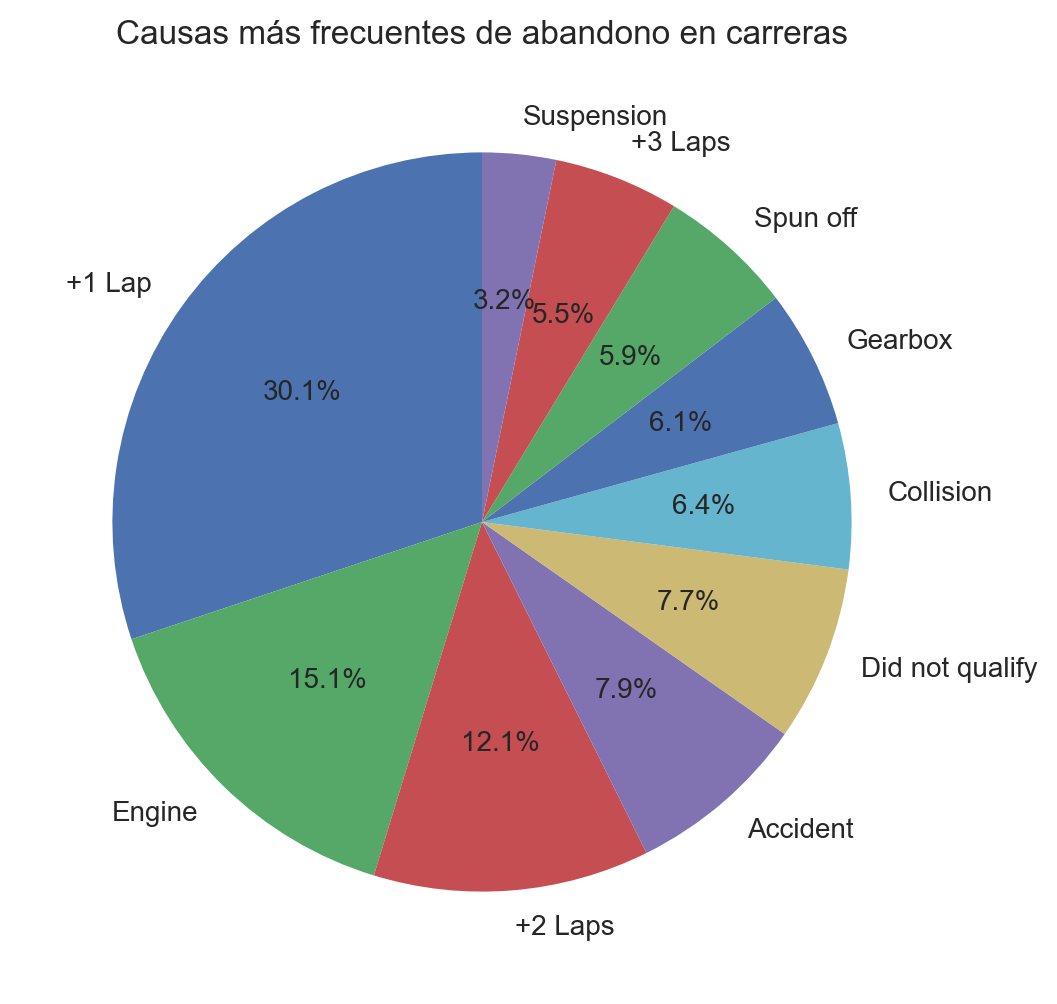

In [49]:


fig, ax = plt.subplots(figsize=(6, 6))

(
    df_results[df_results['statusId'] != 1]
    .groupby('statusId')  
    .size() 
    .nlargest(10) 
    .reset_index(name='count') 
    .merge(df_status, on='statusId', how='left')  
    .pipe(lambda df: ax.pie( 
        df['count'], 
        labels=df['status'], 
        autopct='%1.1f%%', 
        startangle=90
    ))
)

ax.set_title('Causas más frecuentes de abandono en carreras')
plt.show()


### <font  size=3 color="#00586D"> <i class="fa fa-pencil-square-o" aria-hidden="true" style="color:#00586D"></i> Ejercicio 9</font>  


Cuando el análisis de datos se centra en una categoría o subconjunto de datos obtenidos mediante selección condicional, puede resultar cómodo almacenar este resultado intermedio en un *DataFrame*. Además, si no se va a escribir sobre él, no es necesario hacer copia, sino que se puede hacer una asignación (Anexo I del tutorial). Almacenar los resultados correspondientes a carreras terminadas por `Fernando Alonso` en un *DataFrame* denominado `df_results_alo`. Mostrar cuántas son.

<br>

<details>    
<summary>
    <font size=3 color="#00586D"> <i class="fa fa-info-circle"  aria-hidden="true"></i> </font>
</summary>
       
* Se trata de hacer selección condicional y seleccionar los resultados que cumplan ambas condiciones: que el piloto sea `Fernando Alonso`y que haya concluido la carrera.
* La columna `statusId` contiene información sobre la situación de un piloto/coche al final de la carrera, y el valor 1 quiere decir que terminó.  
    
</details>  


In [53]:

df_results_alo = df_results[
    (df_results['driverId'] == df_drivers[df_drivers['surname'] == 'Alonso'].index[0]) &
    (df_results['statusId'] == 1)
]


num_carreras_alo = df_results_alo.shape[0]

print(f"Número de carreras terminadas: {num_carreras_alo}")


Número de carreras terminadas: 257


La columna `position` del *DataFrame* `df_results` (y de `df_results_alo`) contiene la posición en la que un conductor quedó en la carrera correspondiente. Obtener el número de podios (distinguir posiciones primera, segunda y tercera) que hizo `Fernando Alonso` a lo largo de su trayectoria deportiva (hasta el momento).


<br>

<details>    
<summary>
    <font size=3 color="#00586D"> <i class="fa fa-info-circle"  aria-hidden="true"></i> </font>
</summary>
   
    
* La API de *Series* proporciona un método para obtener las veces que aparece cada valor. 
* El resultado es a su vez una *Serie* que, por tanto, se puede ordenar tanto por valor como por índice.
    
</details> 

In [59]:
# Filtrar los resultados de Fernando Alonso y carreras terminadas
df_results_alo = df_results[
    (df_results['driverId'] == df_drivers[df_drivers['surname'] == 'Alonso'].index[0]) &
    (df_results['statusId'] == 1)
]

# Filtrar las posiciones 1, 2 y 3 (podios)
podios_alo = df_results_alo[df_results_alo['position'].isin([1,2,3])]

# Contar el número de veces que aparece cada posición
conteo_podios = podios_alo['position'].value_counts().sort_index()

print(conteo_podios)


position
1.0    32
2.0    40
3.0    34
Name: count, dtype: int64


Mostrar el número de ocasiones en las que `Fernando Alonso` ocupó las posiciones uno a cuatro en la salida (primera y segunda líneas).

<br>

<details>    
<summary>
    <font size=3 color="#00586D"> <i class="fa fa-info-circle"  aria-hidden="true"></i> </font>
</summary>
   
    
* Se trata de obtener las filas en las que el valor `grid` está entre 1 y 4.    
</details> 

In [60]:
salidas_primera_segunda_linea = df_results_alo[(df_results_alo['grid'] >= 1) & (df_results_alo['grid'] <= 4)]

numero_ocasiones = salidas_primera_segunda_linea.shape[0]

print(f"Número de ocasiones en las que Fernando Alonso salió en la primera o segunda línea: {numero_ocasiones}")

Número de ocasiones en las que Fernando Alonso salió en la primera o segunda línea: 90


<div><font size=3 color="#00586D"> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>

<!--comment -->

<div align="right">
<a href="#indice"><font size=5 color="#00586D"><i class="fa fa-arrow-circle-up" aria-hidden="true"></i></font></a>
</div>

---

<a id="section4"></a>
## <font color="#00586D"> 4. Escuderías</font>
<br>

El elemento fundamental en Fórmula 1 es el coche. La diferencia entre unos equipos y otros es tan alta que, para muchos, es una competición entre escuderías. 

### <font  size=3 color="#00586D"> <i class="fa fa-pencil-square-o" aria-hidden="true" style="color:#00586D"></i> Ejercicio 10</font>

Leer los datos de las escudarías, almacenadas en el archivo `data/constructors.csv` y almacenarlos en un *DataFrame* denominado `df_constructors`. Utilizar la primera columna como índice.

In [63]:
df_constructors = pd.read_csv('data/constructors.csv', index_col=0)
df_constructors


,constructorRef,name,nationality,url
constructorId,,,,
1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso
...,...,...,...,...
210,haas,Haas F1 Team,American,http://en.wikipedia.org/wiki/Haas_F1_Team
211,racing_point,Racing Point,British,http://en.wikipedia.org/wiki/Racing_Point_F1_Team
213,alphatauri,AlphaTauri,Italian,http://en.wikipedia.org/wiki/Scuderia_AlphaTauri


In [64]:
df_constructors.info()

<class 'pandas.core.frame.DataFrame'>
Index: 212 entries, 1 to 215
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   constructorRef  212 non-null    object
 1   name            212 non-null    object
 2   nationality     212 non-null    object
 3   url             212 non-null    object
dtypes: object(4)
memory usage: 8.3+ KB


Mostrar los nombres y nacionalidades de los cinco constructores que han ganado más carreras a lo largo de la historia de la competición.


<br>

<details>    
<summary>
    <font size=3 color="#00586D"> <i class="fa fa-info-circle"  aria-hidden="true"></i> </font>
</summary>
      
* Hay que acceder a los resultados correspondientes a victorias, es decir, donde `position==1`.
    
* Extraer las victorias por constructor agrupando por `constructorId`, calculando el número de elementos por grupo, y generando con el resultado un nuevo *DataFrame*. Renombrar la columna correspondiente a `wins`.
    
* Fundir el resultado con `df_constructors`, que contiene los datos de cada constructor.
 
* Mostrar las columnas `name`, `nationality` y `wins` del *DataFrame* resultante.
    
    
</details> 


In [67]:
df_top_constructors = (
    df_results[df_results['position'] == 1] 
    .groupby('constructorId')  
    .size() 
    .reset_index(name='wins') 
    .merge(df_constructors, left_on='constructorId', right_index=True)  
    [['name', 'nationality', 'wins']]  
    .sort_values(by='wins', ascending=False) 
    .head(5) 
)

print(df_top_constructors)


        name nationality  wins
5    Ferrari     Italian   249
0    McLaren     British   184
31  Mercedes      German   128
6   Red Bull    Austrian   120
2   Williams     British   114


Mostrar los puntos (columna `points`) que ganó `Fernando Alonso` con cada constructor, dando además el nombre y la nacionalidad del constructor.


<details>    
<summary>
    <font size=3 color="#00586D"> <i class="fa fa-info-circle"  aria-hidden="true"></i> </font>
</summary>
  
    
* Se trata de agrupar el *DataFrame* `df_results_alo` en función del constructor, y sumar los puntos (`points`) por cada grupo. 
    
* El resultado, representado como un *DataFrame*, se puede fundir con `df_constructors` para mostrar además el nombre del constructor y la nacionalidad.
    
    
</details> 


In [69]:
df_points_per_constructor = (
    df_results_alo
    .groupby('constructorId')['points']
    .sum()
    .reset_index(name='points') 
)


df_alo_with_constructors = (
    df_points_per_constructor
    .merge(df_constructors, left_on='constructorId', right_index=True)  
    [['name', 'nationality', 'points']]
    .sort_values(by='points', ascending=False))

print(df_alo_with_constructors)

             name nationality  points
2         Ferrari     Italian  1180.0
1         Renault      French   464.0
3    Aston Martin     British   255.0
0         McLaren     British   205.0
4  Alpine F1 Team      French   140.0


<div><font size=3 color="#00586D"> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>

<!--comment -->

<div align="right">
<a href="#indice"><font size=5 color="#00586D"><i class="fa fa-arrow-circle-up" aria-hidden="true"></i></font></a>
</div>

---

<a id="section5"></a>
## <font color="#00586D"> 5. Circuitos</font>
<br>

### <font  size=3 color="#00586D"> <i class="fa fa-pencil-square-o" aria-hidden="true" style="color:#00586D"></i> Ejercicio 11</font>

Por otra parte, el archivo `data/circuits.csv` contiene información relativa a cada uno de los circuitos. Leerlo y almacenarlo en el *DataFrame* `df_circuits`, utilizando la primera columna, `circuitId` como índice.

In [70]:
df_circuits = pd.read_csv('data/circuits.csv', index_col=0)

df_circuits.head()

,circuitRef,name,location,country,lat,lng,alt,url
circuitId,,,,,,,,
1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.73800,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,7,http://en.wikipedia.org/wiki/Bahrain_Internati...
4,catalunya,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.57000,2.26111,109,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,130,http://en.wikipedia.org/wiki/Istanbul_Park


Mostrar los 5 circuitos más rápidos, entendiendo como tales aquellos para los que la media de las 100 vueltas más rápidas (cien valores más altos de `fastestLapSpeed`) es más alta.

**Nota:** Obviamente, este criterio es mejorable. Pero es un ejemplo. 

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i> __Nota__: Este ejercicio **es el más difícil**. Quizá se puede dejar para el final.
</div>


<br>

<details>    
<summary>
    <font size=3 color="#00586D"> <i class="fa fa-info-circle"  aria-hidden="true"></i> </font>
</summary>
  
Este ejercicio se puede resolver en varios pasos, y tiene similitudes con los anteriores.
* En primer lugar, se puede añadir `df_races['circuitID']` a `df_results` para poder asociar resultados con circuitos. Siempre es importante indicar de manera explícita qué índices queremos que tenga el conjunto resultante.
* Hay que agrupar el resultado por circuito (`circuitId`).
* Para obtener parte de la información requerida, se puede utilizar `DataFrame.groupby().apply()`. La función pasada a `apply` toma como argumento un *DataFrame*, y devuelve la media de los 100 valores más altos para `fastestLapSpeed`. Al utilizar esta función con `DataFrame.groupby.apply()` devuelve esa información, un escalar, para cada grupo.
* Una vez devuelta la información para cada circuito, se pueden tomar los 5 valores más altos.
* Por último, el resultado se puede convertir a *DataFrame* y se puede hacer un merge con `df_circuits` para mostrar todos los datos de los circuitos.
    
</details> 


In [77]:
df_results_with_circuit = df_results.merge(
    df_races[['circuitId']], left_on='raceId', right_index=True
)

fastest_circuits = (
    df_results_with_circuit.groupby('circuitId')['fastestLapSpeed']
    .apply(lambda x: x.nlargest(100).mean())  
    .sort_values(ascending=False) 
    .head(5)  
    .reset_index(name='avg_fastestLapSpeed')  
)

df_top_circuits = fastest_circuits.merge(
    df_circuits, left_on='circuitId', right_index=True
)

df_top_circuits = df_top_circuits[['name', 'location', 'avg_fastestLapSpeed']]

print(df_top_circuits)


                             name     location  avg_fastestLapSpeed
0    Autodromo Nazionale di Monza        Monza            250.74373
1         Jeddah Corniche Circuit       Jeddah            238.73587
2             Silverstone Circuit  Silverstone            235.30426
3    Circuit de Spa-Francorchamps          Spa            234.34537
4  Las Vegas Strip Street Circuit    Las Vegas            228.72360


Repetir el ejercicio, pero obtener los circuitos más lentos según el criterio anterior, es decir, tomar la media de velocidad en las 100 vueltas más rápidas para cada circuito, y devolver los cinco más lentos. 

<details>    
<summary>
    <font size=3 color="#00586D"> <i class="fa fa-info-circle"  aria-hidden="true"></i> </font>
</summary>
  
Solo hay que cambiar una función con respecto al anterior.
    
</details> 

In [80]:

df_results_with_circuit = df_results.merge(
    df_races[['circuitId']], left_on='raceId', right_index=True
)

slowest_circuits = (
    df_results_with_circuit.groupby('circuitId')['fastestLapSpeed']
    .apply(lambda x: x.nsmallest(100).mean()) 
    .sort_values(ascending=True) 
    .head(5)  
    .reset_index(name='avg_fastestLapSpeed')  
)

df_bottom_circuits = slowest_circuits.merge(
    df_circuits, left_on='circuitId', right_index=True
)

df_bottom_circuits = df_bottom_circuits[['name', 'location', 'avg_fastestLapSpeed']]

print(df_bottom_circuits)


                             name     location  avg_fastestLapSpeed
0               Circuit de Monaco  Monte-Carlo            145.39755
1       Marina Bay Street Circuit   Marina Bay            159.00982
2                     Hungaroring     Budapest            177.54302
3  Shanghai International Circuit     Shanghai            183.91151
4  Circuit de Barcelona-Catalunya     Montmeló            185.31826


<div><font size=3 color="#00586D"> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>

<!--comment -->


### <font  size=3 color="#00586D"> <i class="fa fa-pencil-square-o" aria-hidden="true" style="color:#00586D"></i> Ejercicio 12</font>

Calcular el resultado anterior (los circuitos más rápidos) con los datos relativos a `Fernando Alonso`, almacenados en `df_results_alo`.

<br>

<details>    
<summary>
    <font size=3 color="#00586D"> <i class="fa fa-info-circle"  aria-hidden="true"></i> </font>
</summary>
  
* Solo hay que cambiar el *DataFrame* de partida, que ahora es `df_results_alo`.
    
</details> 

In [82]:

df_results_alo_with_circuit = df_results_alo.merge(
    df_races[['circuitId']], left_on='raceId', right_index=True
)

fastest_circuits_alo = (
    df_results_alo_with_circuit.groupby('circuitId')['fastestLapSpeed']
    .apply(lambda x: x.nlargest(100).mean())  
    .sort_values(ascending=False)  
    .head(5) 
    .reset_index(name='avg_fastestLapSpeed') 
)

df_top_circuits_alo = fastest_circuits_alo.merge(
    df_circuits, left_on='circuitId', right_index=True
)

df_top_circuits_alo = df_top_circuits_alo[['name', 'location', 'avg_fastestLapSpeed']]

print(df_top_circuits_alo)


                             name     location  avg_fastestLapSpeed
0    Autodromo Nazionale di Monza        Monza           243.802364
1         Jeddah Corniche Circuit       Jeddah           240.770500
2  Las Vegas Strip Street Circuit    Las Vegas           231.191000
3             Silverstone Circuit  Silverstone           227.913714
4    Circuit de Spa-Francorchamps          Spa           225.914900


Calcular también en qué circuitos obtuvo `Fernando Alonso`, de media, mejor posición.

<br>

<details>    
<summary>
    <font size=3 color="#00586D"> <i class="fa fa-info-circle"  aria-hidden="true"></i> </font>
</summary>
  
* Se trata de fundir los resultados de alonso con `df_races` para disponer del circuito al que corresponde cada carrera (similar al anterior).
* Después se agrupa el *DataFrame* resultante por `circuitId`, se obtiene la posición media, y se devuelven los cinco valores más pequeños.
* Por último, el resultado se puede fundir con `df_circuits` para que se muestren los datos de los circuitos.
    
</details> 

In [85]:
df_results_alo_with_circuit = df_results_alo.merge(
    df_races[['circuitId']], left_on='raceId', right_index=True
)

best_position_circuits = (
    df_results_alo_with_circuit.groupby('circuitId')['position']
    .mean()  # Calcular la posición media por circuito
    .sort_values(ascending=True)  # Ordenar por posición media (de menor a mayor)
    .head(5)  # Seleccionar los 5 circuitos con mejor posición media
    .reset_index(name='avg_position')  # Convertir a DataFrame
)


df_best_position_circuits = best_position_circuits.merge(
    df_circuits, left_on='circuitId', right_index=True
)

df_best_position_circuits = df_best_position_circuits[['name', 'location', 'avg_position']]

print(df_best_position_circuits)


                             name        location  avg_position
0                   Fuji Speedway           Oyama      1.000000
1  Circuit de Barcelona-Catalunya        Montmeló      3.181818
2                     Nürburgring         Nürburg      3.250000
3     Indianapolis Motor Speedway    Indianapolis      3.500000
4    Korean International Circuit  Yeongam County      3.750000


<div><font size=3 color="#00586D"> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>

<!--comment -->

**Opcional:** Mostar todos los circuitos en un mapa con `folium`. En la libreta de ejercicios con *matplotlib* tenéis un ejemplo de cómo se hace.

In [87]:
!pip install folium

  Obtaining dependency information for folium from https://files.pythonhosted.org/packages/fc/ab/d1f47c48a14e17cd487c8b467b573291fae75477b067241407e7889a3692/folium-0.19.4-py2.py3-none-any.whl.metadata
  Obtaining dependency information for branca>=0.6.0 from https://files.pythonhosted.org/packages/f8/9d/91cddd38bd00170aad1a4b198c47b4ed716be45c234e09b835af41f4e717/branca-0.8.1-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/110.5 kB ? eta -:--:--
   --- ------------------------------------ 10.2/110.5 kB ? eta -:--:--
   -------------- ------------------------ 41.0/110.5 kB 653.6 kB/s eta 0:00:01
   ---------------------------------------- 110.5/110.5 kB 1.1 MB/s eta 0:00:00


In [88]:
import folium

# Diferentes mapas
tiles = 'Stamen Toner'
tiles = 'OpenStreetMap'

europe_figure = folium.Figure(width=600, height=600)
europe_map = folium.Map(location=[50, 6], tiles=tiles, zoom_start=6).add_to(europe_figure)

for _,circuit in df_circuits.iterrows():
    folium.Marker([circuit['lat'], circuit['lng']], popup=circuit['name']).add_to(europe_map)
    
europe_figure

<div align="right">
<a href="#indice"><font size=5 color="#00586D"><i class="fa fa-arrow-circle-up" aria-hidden="true"></i></font></a>
</div>

---

<a id="section6"></a>
## <font color="#00586D"> 6. Alonso vs rivales</font>
<br>

En esta parte del proyecto se valorarán los resultados de `Fernando Alonso` con respecto a sus rivales, es decir, con respecto a los pilotos que compitieron en las mismas carreras que él. Esto requiere manipular los datos, ya que la información no se puede obtener de forma directa.



---

### <font  size=3 color="#00586D"> <i class="fa fa-pencil-square-o" aria-hidden="true" style="color:#00586D"></i> Ejercicio 13</font>
Mostrar los rivales (filas completas) contra los que ha competido Fernando Alonso.

<br>

<details>    
<summary>
    <font size=3 color="#00586D"> <i class="fa fa-info-circle"  aria-hidden="true"></i> </font>
</summary>
  
Anteriormente se filtraron los resultados de las carreras que terminó `Fernando Alonso`, y se almacenaron en `df_results_alo`. Se trata de:
* Seleccionar los datos correspondientes a esas carreras. 
* Acceder a los resultados (pilotos) que compitieron en ellas (y que no sean `Fernando Alonso`). Para ello es muy útil utilizar `Series.isin()`. Obtener los identificadores únicos de los pilotos.
* Por último, seleccionar los datos de estos pilotos en `df_drivers`.
    
</details> 


In [ ]:
...

Obtener los datos de los 10 rivales a los que más veces se ha enfrentado `Fernando Alonso`, y almacenarlos en el *DataFrame* `df_fa_vs`.


<br>

<details>    
<summary>
    <font size=3 color="#00586D"> <i class="fa fa-info-circle"  aria-hidden="true"></i> </font>
</summary>
  
* Seleccionar los resultados (de `df_results`) correspondientes a las carreras en las que compitió `Fernando Alonso`, y que no corresponden a `Fernando Alonso`. 
* Hay que agrupar por piloto ( `driverId`), calcular el tamaño de los grupos, y tomar los 10 mayores.
* Por último, fundir con `df_drivers` para mostrar todos los datos de los pilotos (no solo el id).
    
</details> 

In [ ]:
df_fa_vs = ...
df_fa_vs

<div><font size=3 color="#00586D"> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>

<!--comment -->

A continuación se hará un balance de los resultados de `Fernando Alonso` con respecto a sus rivales. Para ello, es necesario pasar por una serie de pasos intermedios.

### <font  size=3 color="#00586D"> <i class="fa fa-pencil-square-o" aria-hidden="true" style="color:#00586D"></i> Ejercicio 14</font>


Obtener una tabla en la que cada fila represente cada una de las carreras (`raceId`) concluidas por `Fernando Alonso`, cada columna un piloto (`driverId`) que haya participado (y concluido) en alguna de esas carreras, y el resultado la posición (`position`) del piloto. Almacenar el resultado en un *DataFrame* denominado `df_fa_vs_other`.

<br>

<details>    
<summary>
    <font size=3 color="#00586D"> <i class="fa fa-info-circle"  aria-hidden="true"></i> </font>
</summary>
  
* El primer paso, al igual que se ha hecho anteriormente, es obtener los `raceId` de todas las carreras terminadas por `Fernando Alonso`.
* Después, se han de seleccionar aquellos resultados correspondientes a pilotos que han terminado las carreras (`statusId==1`) y en los que `raceId` sea una de las carreras terminadas por `Fernando Alonso` (dos condiciones).
* La tabla puede hacer con `DataFrame.stack()`, fijando primero como índice la carrera y el piloto.
* Se puede hacer el ejercicio con *method chaining*.    
</details> 


In [ ]:
df_fa_vs_other = ...
     
df_fa_vs_other

<div><font size=3 color="#00586D"> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>

<!--comment -->



### <font  size=3 color="#00586D"> <i class="fa fa-pencil-square-o" aria-hidden="true" style="color:#00586D"></i> Ejercicio 15</font>

A partir del *DataFrame* `df_fa_vsp` mostrar los 10 rivales que ha batido más veces `Fernando Alonso`. 


<br>

<details>    
<summary>
    <font size=3 color="#00586D"> <i class="fa fa-info-circle"  aria-hidden="true"></i> </font>
</summary>
  
* Aplicando `Dataframe.apply()` por filas, se puede crear un *DataFrame* en el que si la posición está por encima de la de `Fernando Alonso` el valor es 1, y si no 0. 
* La suma por columnas de este *DataFrame* devuelve una serie con el número de veces que `Fernando Alonso` ha batido a cada rival. 
* Se tomarían los 10 mayores valores. 
* Se puede fundir con `df_drivers` para mostrar también el nombre y los datos de cada piloto.  
</details> 





In [ ]:
#
# COMPLETAR
#

Mostrar ahora los 10 rivales han batido más veces a `Fernando Alonso`. 

<br>

<details>    
<summary>
    <font size=3 color="#00586D"> <i class="fa fa-info-circle"  aria-hidden="true"></i> </font>
</summary>
  
* Se procede de forma similar al anterior, pero cambiando el cuerpo de `DataFrame.apply()`. 
</details> 

In [ ]:
#
# COMPLETAR
#

<div><font size=3 color="#00586D"> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>

<!--comment -->


<div align="right">
<a href="#indice"><font size=5 color="#00586D"><i class="fa fa-arrow-circle-up" aria-hidden="true"></i></font></a>
</div>

---

<a id="section7"></a>
## <font color="#00586D"> 7. Conclusiones y líneas de trabajo para TFM</font>
<br>

Este trabajo ha servido para familiarizarnos con la herramienta *pandas* y hacer algunas operaciones algo más complejas orientadas al análisis. Aunque se trata de un primer proyecto de carácter *instrumental*, desde el punto de vista de los datos nos ha permitido además obtener información en principio desconocida, o al menos en parte. 

Como puede apreciarse, el conjunto de datos es más amplio, y contiene información sobre tiempos por vuelta, temporadas, etc. Si os interesa o apetece, es posible extender el análisis que se ha hecho para que contemple esas y otras cuestiones. 

Existe otro sitio web,[(FastF1)](https://docs.fastf1.dev) en el que se puede acceder a datos de telemetría, posición, etc., que permiten hacer análisis muy minuciosos sobre la conducción, puntos fuertes de los coches, etc. Quienes seais aficionados a la F1 podéis plantearos hacer el TFM con esta temática. 

<div align="right">
<a href="#indice"><font size=5 color="#00586D"><i class="fa fa-arrow-circle-up" aria-hidden="true"></i></font></a>
</div>

---

<div align="right">
<a href="#indice"><font size=6 color="#00586D"><i class="fa fa-coffee" aria-hidden="true"></i></font></a>
</div>